<a href="https://colab.research.google.com/github/hecfrantuis/Proyecto-IA-1/blob/main/Proyecto_AcneI_A1_Modelos_No_Supervisados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Drive - Librerias

In [ ]:
#@title Montar el drive
import os
from google.colab import drive

Ubicacion = "Septimo/IA 1 2026-1/Proyecto/AcneDataset/train" #@param {type:"string"}
path = "/content/drive/My Drive/" + Ubicacion
drive.mount('/content/drive')
os.chdir(path)
print(os.getcwd())

Mounted at /content/drive
/content/drive/My Drive/Septimo/IA 1 2026-1/Proyecto/AcneDataset/train


In [ ]:
# @title Librerias
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern
from scipy.stats import zscore, entropy, stats
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.feature_selection import SelectKBest, f_classif

In [ ]:
# @title DataFrame con etiquetas
data = []

for etiqueta in os.listdir('.'):
    if os.path.isdir(etiqueta):
        for archivo in os.listdir(etiqueta):
            if archivo.endswith(('.jpg', '.png')):
                ruta_completa = os.path.join(etiqueta, archivo)
                img_bgr = cv2.imread(ruta_completa)

                if img_bgr is None:
                    continue

                # ── RGB ──────────────────────────────────────────────
                rojo   = np.mean(img_bgr[:, :, 2])
                verde  = np.mean(img_bgr[:, :, 1])
                azul   = np.mean(img_bgr[:, :, 0])
                contraste = img_bgr.std()

                # ── HSV (detecta inflamación y saturación) ────────────
                img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
                hue_mean = np.mean(img_hsv[:, :, 0])
                sat_mean = np.mean(img_hsv[:, :, 1])
                val_mean = np.mean(img_hsv[:, :, 2])

                # ── LBP — Local Binary Patterns (textura) ─────────────
                gris = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
                lbp  = local_binary_pattern(gris, P=8, R=1, method='uniform')
                lbp_hist, _ = np.histogram(lbp.ravel(),
                                           bins=np.arange(0, 11),
                                           density=True)
                lbp_mean = np.mean(lbp)

                # ── Entropía (rugosidad / complejidad visual) ──────────
                # Histograma de la imagen en escala de grises → entropía
                hist_gris, _ = np.histogram(gris.ravel(), bins=256,
                                            range=(0, 256), density=True)
                hist_gris += 1e-10          # evitar log(0)
                entropia = entropy(hist_gris)

                data.append({
                    'Etiqueta'  : etiqueta,
                    'Rojo'      : rojo,
                    'Verde'     : verde,
                    'Azul'      : azul,
                    'Contraste' : contraste,
                    'Hue'       : hue_mean,
                    'Saturacion': sat_mean,
                    'Valor_HSV' : val_mean,
                    'LBP_Mean'  : lbp_mean,
                    'Entropia'  : entropia,
                })

df_proyecto = pd.DataFrame(data)
print(f"Dataset inicial: {df_proyecto.shape}")
print(df_proyecto['Etiqueta'].value_counts())

Dataset inicial: (2778, 10)
Etiqueta
Blackheads    735
Cyst          645
Papules       621
Pustules      584
Whiteheads    193
Name: count, dtype: int64


#Selección de Características

Dimensiones: X_scaled=(2778, 9) | y=(2778,)

Ranking de características:
   Feature    F_Score       P_Value
  Entropia 188.469600 4.638511e-143
 Valor_HSV 105.286800  1.337387e-83
      Rojo 103.745579  1.923212e-82
  LBP_Mean  89.618778  9.940607e-72
     Verde  74.602064  3.882311e-60
      Azul  70.574123  5.425725e-57
Saturacion  55.898714  2.109416e-45
 Contraste  22.571546  2.277749e-18
       Hue  21.193754  3.102531e-17


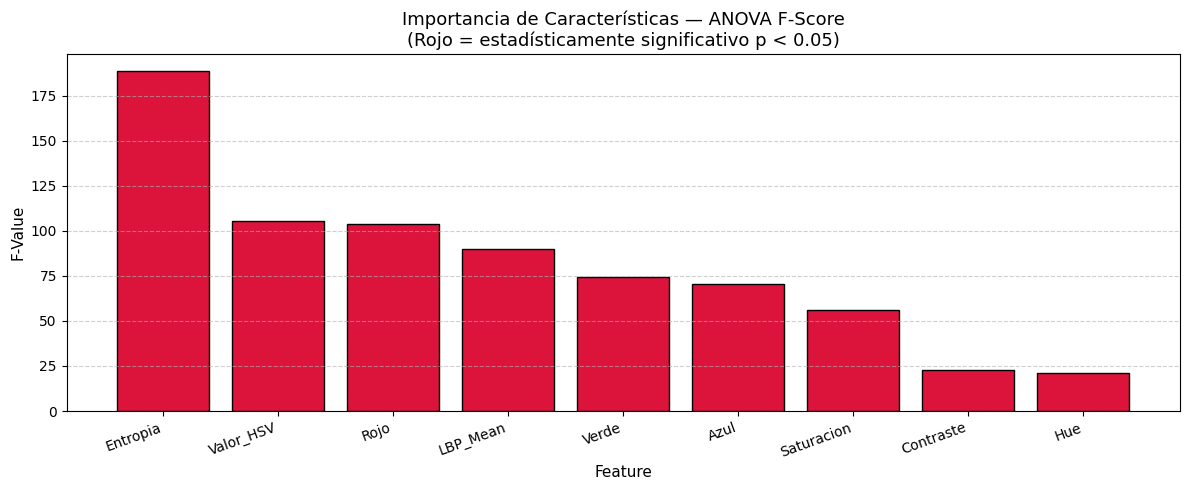

In [ ]:
# @title Seleccion de las caracteristicas mas importantes
# Etiquetas
le = LabelEncoder()
df_proyecto['Etiqueta_Num'] = le.fit_transform(df_proyecto['Etiqueta'])

columnas_numericas = ['Rojo', 'Verde', 'Azul', 'Contraste',
                      'Hue', 'Saturacion', 'Valor_HSV', 'LBP_Mean', 'Entropia']

# Separamos X y y SIEMPRE desde df_proyecto
X = df_proyecto[columnas_numericas]          # features
y = df_proyecto['Etiqueta_Num']              # target (numérico)

# Escalamiento con RobustScaler (más robusto ante los outliers residuales)
scaler   = RobustScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dimensiones: X_scaled={X_scaled.shape} | y={y.shape}")
# ▲ Deben coincidir — este era tu error: antes usabas 'y' (df_proyecto) en vez de y

# ── SelectKBest con ANOVA ─────────────────────────────────────────────────────
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_scaled, y)          # ← y, NO y

# ── Visualización de importancia ──────────────────────────────────────────────
scores_df = pd.DataFrame({
    'Feature': columnas_numericas,
    'F_Score': selector.scores_,
    'P_Value': selector.pvalues_
}).sort_values('F_Score', ascending=False)

print("\nRanking de características:")
print(scores_df.to_string(index=False))

plt.figure(figsize=(12, 5))
colores = ['crimson' if p < 0.05 else 'steelblue'
           for p in scores_df['P_Value']]
plt.bar(scores_df['Feature'], scores_df['F_Score'],
        color=colores, edgecolor='black')
plt.title("Importancia de Características — ANOVA F-Score\n"
          "(Rojo = estadísticamente significativo p < 0.05)", fontsize=13)
plt.xlabel("Feature", fontsize=11)
plt.ylabel("F-Value", fontsize=11)
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── Seleccionamos las K mejores (ej. k=5) para el modelo final ────────────────
K_MEJOR = 5
selector_k = SelectKBest(score_func=f_classif, k=K_MEJOR)
X_final    = selector_k.fit_transform(X_scaled, y)
features_seleccionadas = np.array(columnas_numericas)[selector_k.get_support()]

In [ ]:
print("Características seleccionadas:")
print(features_seleccionadas)

print("Dimensión final de X_final:", X_final.shape)

Características seleccionadas:
['Rojo' 'Verde' 'Valor_HSV' 'LBP_Mean' 'Entropia']
Dimensión final de X_final: (2778, 5)


In [ ]:
# @title 1. Preparación general para clustering

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors

# Etiquetas reales solo para interpretación final
y_real = np.array(y).ravel()

print("Características seleccionadas:")
print(features_seleccionadas)

print("\nDimensión de X_final:", X_final.shape)
print("Número de clases reales:", len(np.unique(y_real)))
print("Clases:", df_proyecto["Etiqueta"].unique())

Características seleccionadas:
['Rojo' 'Verde' 'Valor_HSV' 'LBP_Mean' 'Entropia']

Dimensión de X_final: (2778, 5)
Número de clases reales: 5
Clases: ['Blackheads' 'Cyst' 'Papules' 'Pustules' 'Whiteheads']


In [ ]:
# @title 2. Función de evaluación de clustering

def evaluar_clustering(X, labels, y_real=None, nombre_modelo="Modelo"):
    labels = np.array(labels)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_ruido = np.sum(labels == -1)

    resultado = {
        "Modelo": nombre_modelo,
        "Clusters": n_clusters,
        "Ruido": n_ruido
    }

    # Métricas internas
    if n_clusters >= 2:
        resultado["Silhouette"] = silhouette_score(X, labels)
        resultado["Davies_Bouldin"] = davies_bouldin_score(X, labels)
        resultado["Calinski_Harabasz"] = calinski_harabasz_score(X, labels)
    else:
        resultado["Silhouette"] = np.nan
        resultado["Davies_Bouldin"] = np.nan
        resultado["Calinski_Harabasz"] = np.nan

    # Métricas externas: solo para comparar con etiquetas reales, no para entrenar
    if y_real is not None:
        resultado["ARI"] = adjusted_rand_score(y_real, labels)
        resultado["NMI"] = normalized_mutual_info_score(y_real, labels)

    return resultado

In [ ]:
# @title 3. K-Means: método del codo y Silhouette

resultados_kmeans = []
inercias = []

rango_k = range(2, 11)

for k in rango_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = modelo.fit_predict(X_final)

    inercias.append(modelo.inertia_)

    resultado = evaluar_clustering(
        X_final,
        clusters,
        y_real=y_real,
        nombre_modelo=f"K-Means K={k}"
    )

    resultado["K"] = k
    resultados_kmeans.append(resultado)

df_kmeans = pd.DataFrame(resultados_kmeans)

display(df_kmeans[[
    "K",
    "Silhouette",
    "Davies_Bouldin",
    "Calinski_Harabasz",
    "ARI",
    "NMI"
]])

,K,Silhouette,Davies_Bouldin,Calinski_Harabasz,ARI,NMI
0,2,0.742307,0.389524,2354.210951,0.022950,0.065808
1,3,0.322544,0.950804,2372.648090,0.023539,0.057300
2,4,0.288196,0.998215,2251.122817,0.039659,0.069154
3,5,0.274543,1.080820,2037.121486,0.041027,0.073745
4,6,0.249887,1.069376,1884.476755,0.042062,0.072015
5,7,0.259998,1.050971,1813.198828,0.035082,0.081638
6,8,0.259849,0.992061,1777.529520,0.030796,0.081692
7,9,0.265513,1.032827,1724.476905,0.028749,0.078820
8,10,0.248357,1.054895,1673.976375,0.032445,0.084046


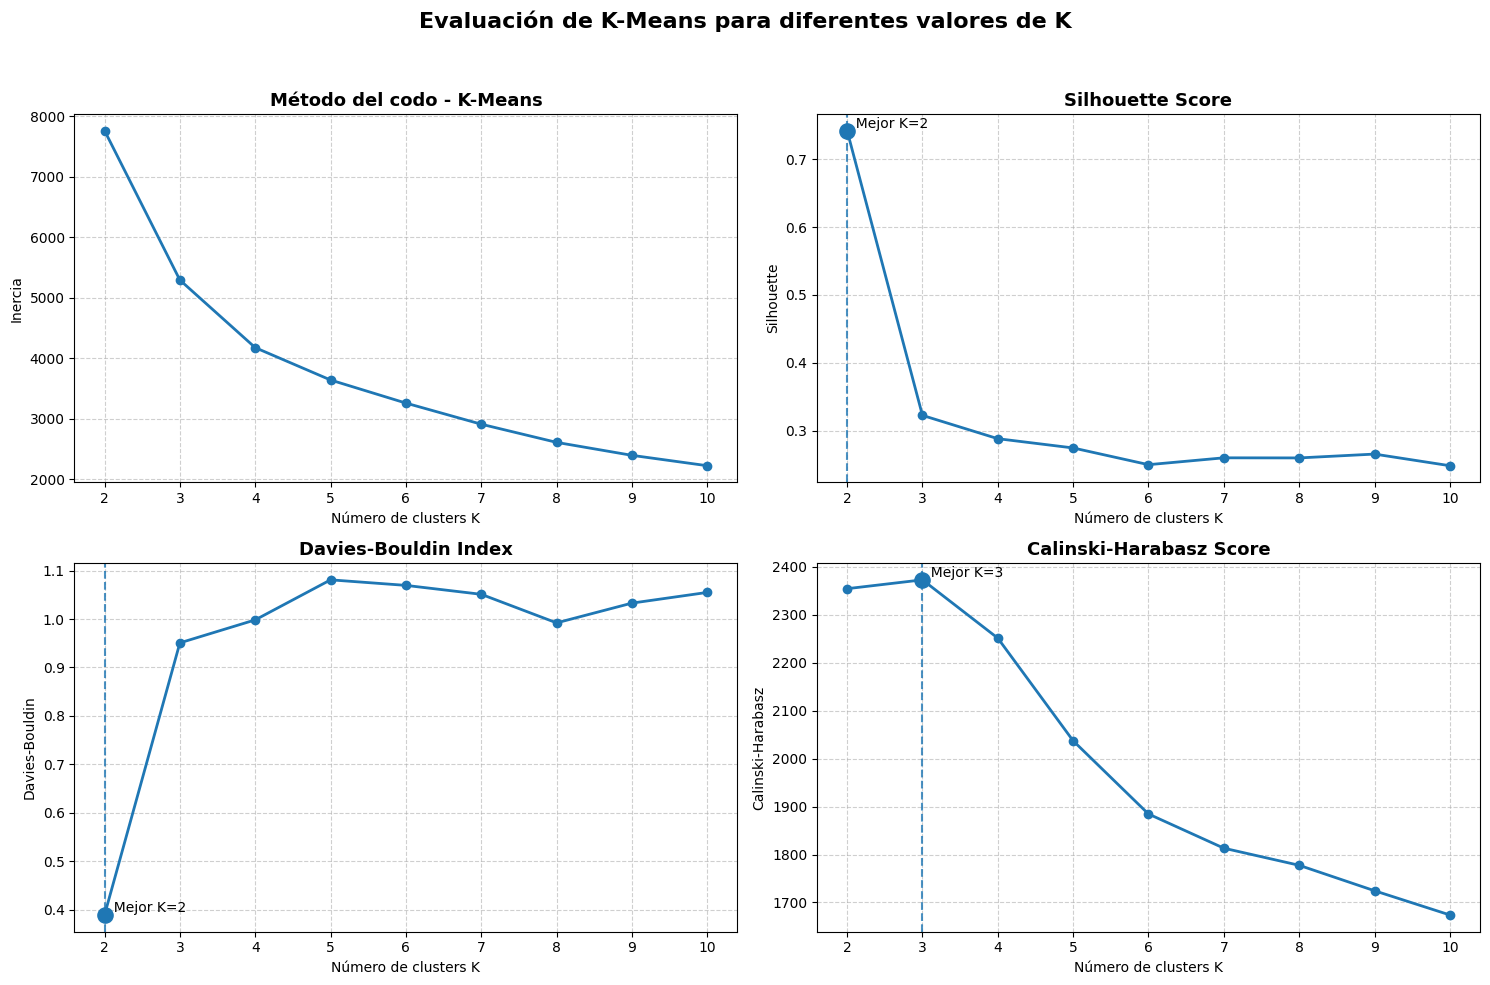

In [ ]:
# @title 4. Gráficas mejor distribuidas: Codo, Silhouette, Davies-Bouldin y Calinski-Harabasz

# Mejores valores según cada métrica
best_k_sil = df_kmeans.loc[df_kmeans["Silhouette"].idxmax(), "K"]
best_sil = df_kmeans["Silhouette"].max()

best_k_db = df_kmeans.loc[df_kmeans["Davies_Bouldin"].idxmin(), "K"]
best_db = df_kmeans["Davies_Bouldin"].min()

best_k_ch = df_kmeans.loc[df_kmeans["Calinski_Harabasz"].idxmax(), "K"]
best_ch = df_kmeans["Calinski_Harabasz"].max()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ─────────────────────────────────────────────
# 1. Método del codo
# ─────────────────────────────────────────────
axes[0, 0].plot(list(rango_k), inercias, marker="o", linewidth=2)
axes[0, 0].set_title("Método del codo - K-Means", fontsize=13, fontweight="bold")
axes[0, 0].set_xlabel("Número de clusters K")
axes[0, 0].set_ylabel("Inercia")
axes[0, 0].set_xticks(list(rango_k))
axes[0, 0].grid(True, linestyle="--", alpha=0.6)

# ─────────────────────────────────────────────
# 2. Silhouette Score
# Mayor es mejor
# ─────────────────────────────────────────────
axes[0, 1].plot(df_kmeans["K"], df_kmeans["Silhouette"], marker="o", linewidth=2)
axes[0, 1].axvline(best_k_sil, linestyle="--", alpha=0.8)
axes[0, 1].scatter(best_k_sil, best_sil, s=120, zorder=5)
axes[0, 1].set_title("Silhouette Score", fontsize=13, fontweight="bold")
axes[0, 1].set_xlabel("Número de clusters K")
axes[0, 1].set_ylabel("Silhouette")
axes[0, 1].set_xticks(list(rango_k))
axes[0, 1].grid(True, linestyle="--", alpha=0.6)
axes[0, 1].text(
    best_k_sil,
    best_sil,
    f"  Mejor K={int(best_k_sil)}",
    fontsize=10,
    verticalalignment="bottom"
)

# ─────────────────────────────────────────────
# 3. Davies-Bouldin
# Menor es mejor
# ─────────────────────────────────────────────
axes[1, 0].plot(df_kmeans["K"], df_kmeans["Davies_Bouldin"], marker="o", linewidth=2)
axes[1, 0].axvline(best_k_db, linestyle="--", alpha=0.8)
axes[1, 0].scatter(best_k_db, best_db, s=120, zorder=5)
axes[1, 0].set_title("Davies-Bouldin Index", fontsize=13, fontweight="bold")
axes[1, 0].set_xlabel("Número de clusters K")
axes[1, 0].set_ylabel("Davies-Bouldin")
axes[1, 0].set_xticks(list(rango_k))
axes[1, 0].grid(True, linestyle="--", alpha=0.6)
axes[1, 0].text(
    best_k_db,
    best_db,
    f"  Mejor K={int(best_k_db)}",
    fontsize=10,
    verticalalignment="bottom"
)

# ─────────────────────────────────────────────
# 4. Calinski-Harabasz
# Mayor es mejor
# ─────────────────────────────────────────────
axes[1, 1].plot(df_kmeans["K"], df_kmeans["Calinski_Harabasz"], marker="o", linewidth=2)
axes[1, 1].axvline(best_k_ch, linestyle="--", alpha=0.8)
axes[1, 1].scatter(best_k_ch, best_ch, s=120, zorder=5)
axes[1, 1].set_title("Calinski-Harabasz Score", fontsize=13, fontweight="bold")
axes[1, 1].set_xlabel("Número de clusters K")
axes[1, 1].set_ylabel("Calinski-Harabasz")
axes[1, 1].set_xticks(list(rango_k))
axes[1, 1].grid(True, linestyle="--", alpha=0.6)
axes[1, 1].text(
    best_k_ch,
    best_ch,
    f"  Mejor K={int(best_k_ch)}",
    fontsize=10,
    verticalalignment="bottom"
)

plt.suptitle(
    "Evaluación de K-Means para diferentes valores de K",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
# @title 5. Mejor modelo K-Means según Silhouette

mejor_kmeans = df_kmeans.sort_values("Silhouette", ascending=False).iloc[0]
mejor_k = int(mejor_kmeans["K"])

print("Mejor K seleccionado:", mejor_k)
print(mejor_kmeans)

kmeans_final = KMeans(n_clusters=mejor_k, random_state=42, n_init=10)
clusters_kmeans = kmeans_final.fit_predict(X_final)

df_proyecto["Cluster_KMeans"] = clusters_kmeans

print("\nTabla cruzada: clase real vs cluster K-Means")
tabla_kmeans = pd.crosstab(
    df_proyecto["Etiqueta"],
    df_proyecto["Cluster_KMeans"]
)

display(tabla_kmeans)

Mejor K seleccionado: 2
Modelo               K-Means K=2
Clusters                       2
Ruido                          0
Silhouette              0.742307
Davies_Bouldin          0.389524
Calinski_Harabasz    2354.210951
ARI                      0.02295
NMI                     0.065808
K                              2
Name: 0, dtype: object

Tabla cruzada: clase real vs cluster K-Means


Cluster_KMeans,0,1
Etiqueta,,
Blackheads,732,3
Cyst,632,13
Papules,613,8
Pustules,582,2
Whiteheads,122,71


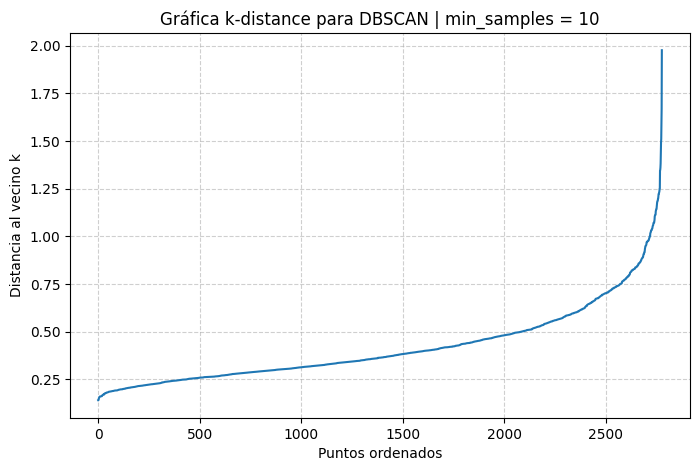

,eps,min_samples,Clusters,Ruido,Porcentaje_Ruido,Silhouette,Davies_Bouldin,Calinski_Harabasz,ARI,NMI
0,0.363,3,89,282,10.151188,-0.284943,1.225188,50.730753,0.026696,0.171289
1,0.363,5,39,515,18.538517,-0.324733,1.356148,79.593188,0.027176,0.131075
2,0.363,10,11,931,33.513319,-0.270003,1.533422,173.609293,0.022138,0.072162
3,0.363,15,7,1235,44.456443,-0.116332,1.414901,204.932311,0.014377,0.059204
4,0.407,3,69,208,7.487401,-0.280498,1.133468,60.968807,0.028786,0.172240
5,0.407,5,33,370,13.318934,-0.255654,1.183727,97.986260,0.029134,0.140890
6,0.407,10,6,731,26.313895,-0.137959,1.682691,333.273209,0.025900,0.066841
7,0.407,15,7,957,34.449244,-0.080546,1.639886,302.655682,0.022726,0.073419
8,0.468,3,49,146,5.255580,-0.253443,1.059803,77.527411,0.025836,0.151412
9,0.468,5,21,267,9.611231,-0.187677,1.198517,142.709807,0.026396,0.119419


In [ ]:
# @title 6. DBSCAN: búsqueda de eps y min_samples

# Sugerencia inicial para min_samples
min_samples_base = max(5, 2 * X_final.shape[1])

neighbors = NearestNeighbors(n_neighbors=min_samples_base)
neighbors_fit = neighbors.fit(X_final)
distances, indices = neighbors_fit.kneighbors(X_final)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8,5))
plt.plot(k_distances)
plt.title(f"Gráfica k-distance para DBSCAN | min_samples = {min_samples_base}")
plt.xlabel("Puntos ordenados")
plt.ylabel("Distancia al vecino k")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

eps_values = np.unique(
    np.round(np.percentile(k_distances, [50, 60, 70, 75, 80, 85, 90, 95]), 3)
)

min_samples_values = sorted(list(set([
    3,
    5,
    min_samples_base,
    max(10, 3 * X_final.shape[1])
])))

resultados_dbscan = []

for eps in eps_values:
    for min_samples in min_samples_values:

        modelo = DBSCAN(eps=eps, min_samples=min_samples)
        clusters = modelo.fit_predict(X_final)

        resultado = evaluar_clustering(
            X_final,
            clusters,
            y_real=y_real,
            nombre_modelo=f"DBSCAN eps={eps}, min_samples={min_samples}"
        )

        resultado["eps"] = eps
        resultado["min_samples"] = min_samples
        resultado["Porcentaje_Ruido"] = resultado["Ruido"] / len(clusters) * 100

        resultados_dbscan.append(resultado)

df_dbscan = pd.DataFrame(resultados_dbscan)

display(df_dbscan[[
    "eps",
    "min_samples",
    "Clusters",
    "Ruido",
    "Porcentaje_Ruido",
    "Silhouette",
    "Davies_Bouldin",
    "Calinski_Harabasz",
    "ARI",
    "NMI"
]])

In [ ]:
# @title 7. Mejor modelo DBSCAN

df_dbscan_validos = df_dbscan[
    (df_dbscan["Clusters"] >= 2) &
    (df_dbscan["Porcentaje_Ruido"] < 60) &
    (df_dbscan["Silhouette"].notna())
].copy()

if len(df_dbscan_validos) > 0:

    mejor_dbscan = df_dbscan_validos.sort_values(
        ["Silhouette", "Porcentaje_Ruido"],
        ascending=[False, True]
    ).iloc[0]

    print("Mejor configuración DBSCAN:")
    print(mejor_dbscan)

    dbscan_final = DBSCAN(
        eps=mejor_dbscan["eps"],
        min_samples=int(mejor_dbscan["min_samples"])
    )

    clusters_dbscan = dbscan_final.fit_predict(X_final)
    df_proyecto["Cluster_DBSCAN"] = clusters_dbscan

    print("\nTabla cruzada: clase real vs cluster DBSCAN")
    tabla_dbscan = pd.crosstab(
        df_proyecto["Etiqueta"],
        df_proyecto["Cluster_DBSCAN"]
    )

    display(tabla_dbscan)

else:
    print("DBSCAN no encontró una configuración adecuada.")
    clusters_dbscan = None

Mejor configuración DBSCAN:
Modelo               DBSCAN eps=0.827, min_samples=5
Clusters                                           3
Ruido                                             24
Silhouette                                  0.538492
Davies_Bouldin                              1.401591
Calinski_Harabasz                         828.919305
ARI                                         0.023187
NMI                                         0.086334
eps                                            0.827
min_samples                                        5
Porcentaje_Ruido                            0.863931
Name: 29, dtype: object

Tabla cruzada: clase real vs cluster DBSCAN


Cluster_DBSCAN,-1,0,1,2
Etiqueta,,,,
Blackheads,7,728,0,0
Cyst,8,629,8,0
Papules,1,612,8,0
Pustules,7,577,0,0
Whiteheads,1,121,4,67


In [ ]:
# @title 8. Clustering jerárquico: búsqueda formal

resultados_jerarquico = []

for k in range(2, 11):
    for linkage in ["ward", "complete", "average", "single"]:

        modelo = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        clusters = modelo.fit_predict(X_final)

        resultado = evaluar_clustering(
            X_final,
            clusters,
            y_real=y_real,
            nombre_modelo=f"Jerárquico K={k}, linkage={linkage}"
        )

        resultado["K"] = k
        resultado["Linkage"] = linkage

        resultados_jerarquico.append(resultado)

df_jerarquico = pd.DataFrame(resultados_jerarquico)

display(df_jerarquico[[
    "K",
    "Linkage",
    "Silhouette",
    "Davies_Bouldin",
    "Calinski_Harabasz",
    "ARI",
    "NMI"
]])

,K,Linkage,Silhouette,Davies_Bouldin,Calinski_Harabasz,ARI,NMI
0,2,ward,0.762897,0.243972,1951.583217,0.022082,0.083270
1,2,complete,0.756214,0.294024,2203.401213,0.021887,0.071579
2,2,average,0.730985,0.445803,2315.215106,0.022943,0.061114
3,2,single,0.512329,0.382594,15.116229,-0.000229,0.001858
4,3,ward,0.323578,0.893610,1926.455661,0.020311,0.069640
5,3,complete,0.311816,0.987282,1935.745261,0.021986,0.057445
6,3,average,0.604499,0.504840,1317.393349,0.023165,0.082503
7,3,single,0.394872,0.382374,9.634610,-0.000305,0.002473
8,4,ward,0.234832,1.042840,1884.025644,0.030710,0.068876
9,4,complete,0.259938,0.951616,1468.743310,0.021017,0.061041


In [ ]:
# @title 9. Mejor modelo jerárquico

mejor_jerarquico = df_jerarquico.sort_values("Silhouette", ascending=False).iloc[0]

print("Mejor configuración jerárquica:")
print(mejor_jerarquico)

jerarquico_final = AgglomerativeClustering(
    n_clusters=int(mejor_jerarquico["K"]),
    linkage=mejor_jerarquico["Linkage"]
)

clusters_jerarquico = jerarquico_final.fit_predict(X_final)
df_proyecto["Cluster_Jerarquico"] = clusters_jerarquico

print("\nTabla cruzada: clase real vs cluster jerárquico")
tabla_jerarquico = pd.crosstab(
    df_proyecto["Etiqueta"],
    df_proyecto["Cluster_Jerarquico"]
)

display(tabla_jerarquico)

Mejor configuración jerárquica:
Modelo               Jerárquico K=2, linkage=ward
Clusters                                        2
Ruido                                           0
Silhouette                               0.762897
Davies_Bouldin                           0.243972
Calinski_Harabasz                     1951.583217
ARI                                      0.022082
NMI                                       0.08327
K                                               2
Linkage                                      ward
Name: 0, dtype: object

Tabla cruzada: clase real vs cluster jerárquico


Cluster_Jerarquico,0,1
Etiqueta,,
Blackheads,735,0
Cyst,645,0
Papules,621,0
Pustules,584,0
Whiteheads,126,67


In [ ]:
# @title 10. Comparación final de algoritmos

comparacion = []

comparacion.append(
    evaluar_clustering(
        X_final,
        clusters_kmeans,
        y_real,
        nombre_modelo=f"K-Means K={mejor_k}"
    )
)

comparacion.append(
    evaluar_clustering(
        X_final,
        clusters_jerarquico,
        y_real,
        nombre_modelo=f"Jerárquico K={int(mejor_jerarquico['K'])}, {mejor_jerarquico['Linkage']}"
    )
)

if clusters_dbscan is not None:
    comparacion.append(
        evaluar_clustering(
            X_final,
            clusters_dbscan,
            y_real,
            nombre_modelo="DBSCAN"
        )
    )

df_comparacion = pd.DataFrame(comparacion)

display(df_comparacion[[
    "Modelo",
    "Clusters",
    "Ruido",
    "Silhouette",
    "Davies_Bouldin",
    "Calinski_Harabasz",
    "ARI",
    "NMI"
]])

,Modelo,Clusters,Ruido,Silhouette,Davies_Bouldin,Calinski_Harabasz,ARI,NMI
0,K-Means K=2,2,0,0.742307,0.389524,2354.210951,0.022950,0.065808
1,"Jerárquico K=2, ward",2,0,0.762897,0.243972,1951.583217,0.022082,0.083270
2,DBSCAN,3,24,0.538492,1.401591,828.919305,0.023187,0.086334


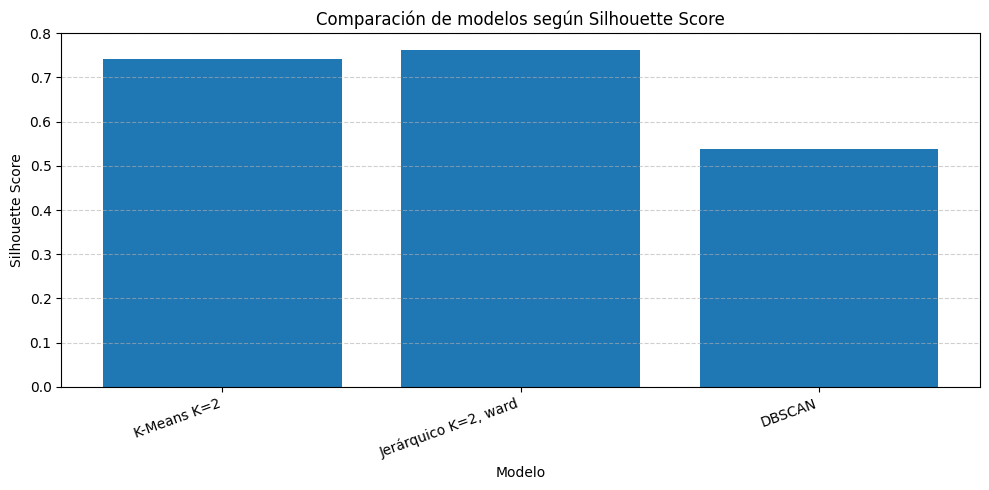

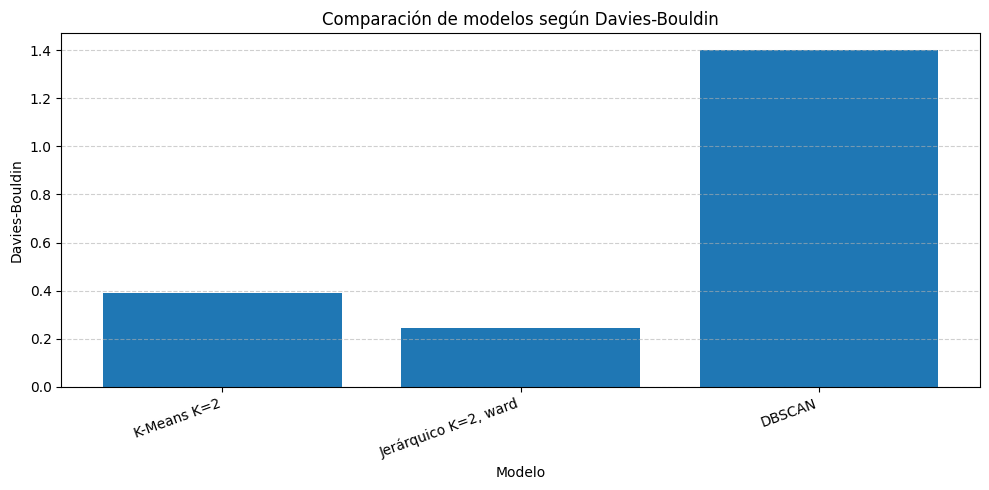

In [ ]:
# @title 11. Gráfica comparativa de modelos

plt.figure(figsize=(10,5))
plt.bar(df_comparacion["Modelo"], df_comparacion["Silhouette"])
plt.title("Comparación de modelos según Silhouette Score")
plt.xlabel("Modelo")
plt.ylabel("Silhouette Score")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.bar(df_comparacion["Modelo"], df_comparacion["Davies_Bouldin"])
plt.title("Comparación de modelos según Davies-Bouldin")
plt.xlabel("Modelo")
plt.ylabel("Davies-Bouldin")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

#APRENDIZAJE NO SUPERVISADO-REDUCCIÓN DIMENSIONAL


##Librerías

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf


from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.utils.class_weight import compute_class_weight

##RUTA DATASET

In [ ]:
ruta_base = "/content/drive/MyDrive/Septimo/IA 1 2026-1/Proyecto/AcneDataset"

ruta_train = os.path.join(ruta_base, "train")
ruta_valid = os.path.join(ruta_base, "valid")
ruta_test  = os.path.join(ruta_base, "test")

print("Existe train:", os.path.exists(ruta_train))
print("Existe valid:", os.path.exists(ruta_valid))
print("Existe test :", os.path.exists(ruta_test))

print("\nClases en train:")
print(os.listdir(ruta_train))

##CARGAR IMAGENES

In [ ]:
img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    ruta_train,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="int",
    shuffle=True,
    seed=42
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    ruta_valid,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="int",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    ruta_test,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="int",
    shuffle=False
)

class_names = train_ds.class_names
num_clases = len(class_names)

print("Clases:", class_names)
print("Número de clases:", num_clases)

##OPTIMIZAR CARGA

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
valid_ds = valid_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

##PESOS DE CLASE PARA EL DESBALANCE DE DATOS

In [ ]:
y_train_img = []

for imagenes, etiquetas in train_ds:
    y_train_img.extend(etiquetas.numpy())

y_train_img = np.array(y_train_img)

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_img),
    y=y_train_img
)

dict_weights_cnn = {i: weights[i] for i in range(len(weights))}

print("Pesos por clase:")
for i, clase in enumerate(class_names):
    print(f"{i} - {clase}: {dict_weights_cnn[i]:.4f}")

##Extraer las caracteristicas

In [ ]:
# Usamos MobileNetV2 solo como extractor de características
extractor = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
    pooling="avg"
)

X_features = []
y_labels = []

for imagenes, etiquetas in train_ds:
    imagenes_pre = tf.keras.applications.mobilenet_v2.preprocess_input(imagenes)
    features = extractor.predict(imagenes_pre, verbose=0)

    X_features.append(features)
    y_labels.extend(etiquetas.numpy())

X_features = np.vstack(X_features)
y_labels = np.array(y_labels)

print("Características extraídas:", X_features.shape)
print("Etiquetas:", y_labels.shape)

##Normalizar caracteristicas

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

print("Datos normalizados:", X_scaled.shape)

#1. PCA-2 componentes para visualizar

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA

# Estilo claro
sns.set_style("whitegrid")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

pca_2 = PCA(n_components=2, random_state=42)
X_pca_2 = pca_2.fit_transform(X_scaled)

df_comparacion = pd.DataFrame({
    "Feature 1": X_scaled[:, 0],
    "Feature 2": X_scaled[:, 1],
    "PCA1": X_pca_2[:, 0],
    "PCA2": X_pca_2[:, 1],
    "Clase": [class_names[i] for i in y_labels]
})

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(
    data=df_comparacion,
    x="Feature 1",
    y="Feature 2",
    hue="Clase",
    alpha=0.7
)
plt.title("Antes de aplicar PCA")
plt.xlabel("Feature 1 original")
plt.ylabel("Feature 2 original")

plt.subplot(1, 2, 2)
sns.scatterplot(
    data=df_comparacion,
    x="PCA1",
    y="PCA2",
    hue="Clase",
    alpha=0.7
)
plt.title("Después de aplicar PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.tight_layout()
plt.show()

print("Varianza explicada por PCA1 y PCA2:")
print(pca_2.explained_variance_ratio_)
print("Varianza total explicada:", pca_2.explained_variance_ratio_.sum())

##2. Random Forest vs PCA + Random Forest
Extraer características también para validación y test

In [ ]:
def extraer_features(dataset):
    X = []
    y = []

    for imagenes, etiquetas in dataset:
        imagenes_pre = tf.keras.applications.mobilenet_v2.preprocess_input(imagenes)
        features = extractor.predict(imagenes_pre, verbose=0)

        X.append(features)
        y.extend(etiquetas.numpy())

    return np.vstack(X), np.array(y)


X_train_feat, y_train_feat = extraer_features(train_ds)
X_valid_feat, y_valid_feat = extraer_features(valid_ds)
X_test_feat, y_test_feat = extraer_features(test_ds)

print("Train:", X_train_feat.shape)
print("Valid:", X_valid_feat.shape)
print("Test:", X_test_feat.shape)

##Random Forest sin PCA

In [ ]:
scaler_rf = StandardScaler()

X_train_scaled = scaler_rf.fit_transform(X_train_feat)
X_test_scaled = scaler_rf.transform(X_test_feat)

rf_original = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_original.fit(X_train_scaled, y_train_feat)

y_pred_rf = rf_original.predict(X_test_scaled)

acc_rf = accuracy_score(y_test_feat, y_pred_rf)
bacc_rf = balanced_accuracy_score(y_test_feat, y_pred_rf)

print("Random Forest sin PCA")
print("Accuracy:", round(acc_rf, 4))
print("Balanced Accuracy:", round(bacc_rf, 4))

##PCA con 100 componentes + Random Forest

In [ ]:
pca_100 = PCA(n_components=200, random_state=42)

X_train_pca = pca_100.fit_transform(X_train_scaled)
X_test_pca = pca_100.transform(X_test_scaled)

print("Dimensión original:", X_train_scaled.shape)
print("Dimensión con PCA:", X_train_pca.shape)
print("Varianza explicada con 200 componentes:", round(pca_100.explained_variance_ratio_.sum(), 4))
rf_pca = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_pca.fit(X_train_pca, y_train_feat)

y_pred_rf_pca = rf_pca.predict(X_test_pca)

acc_rf_pca = accuracy_score(y_test_feat, y_pred_rf_pca)
bacc_rf_pca = balanced_accuracy_score(y_test_feat, y_pred_rf_pca)

print("PCA + Random Forest")
print("Accuracy:", round(acc_rf_pca, 4))
print("Balanced Accuracy:", round(bacc_rf_pca, 4))

##Comparación

In [ ]:
comparacion_pca = pd.DataFrame({
    "Modelo": ["Random Forest sin PCA", "PCA + Random Forest"],
    "Accuracy": [acc_rf, acc_rf_pca],
    "Balanced Accuracy": [bacc_rf, bacc_rf_pca]
})

comparacion_pca

plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparacion_pca,
    x="Modelo",
    y="Accuracy",
    edgecolor="black"
)

plt.title("Comparación Random Forest vs PCA + Random Forest")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

#3. t-SNE
t-SNE para visualización

In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=50,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

df_tsne = pd.DataFrame({
    "TSNE1": X_tsne[:, 0],
    "TSNE2": X_tsne[:, 1],
    "Clase": [class_names[i] for i in y_labels]
})

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_tsne,
    x="TSNE1",
    y="TSNE2",
    hue="Clase",
    alpha=0.7
)

plt.title("Reducción dimensional con t-SNE")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

#Comparación visual de las gráficas

In [ ]:
# ============================================
# Comparación visual:
# Antes de PCA, PCA, t-SNE y PCA 200 + t-SNE
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

sns.set_style("whitegrid")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

# -------------------------------
# PCA 2D
# -------------------------------
pca_2 = PCA(n_components=2, random_state=42)
X_pca_2 = pca_2.fit_transform(X_scaled)

# -------------------------------
# t-SNE directo
# -------------------------------
tsne_directo = TSNE(
    n_components=2,
    perplexity=50,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne_directo.fit_transform(X_scaled)

# -------------------------------
# PCA 100 + t-SNE
# -------------------------------
pca_100 = PCA(n_components=200, random_state=42)
X_pca_100 = pca_100.fit_transform(X_scaled)

tsne_pca = TSNE(
    n_components=2,
    perplexity=50,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne_pca = tsne_pca.fit_transform(X_pca_100)

# -------------------------------
# DataFrame para graficar
# -------------------------------
df_visual = pd.DataFrame({
    "Feature 1": X_scaled[:, 0],
    "Feature 2": X_scaled[:, 1],
    "PCA1": X_pca_2[:, 0],
    "PCA2": X_pca_2[:, 1],
    "TSNE1": X_tsne[:, 0],
    "TSNE2": X_tsne[:, 1],
    "TSNE_PCA1": X_tsne_pca[:, 0],
    "TSNE_PCA2": X_tsne_pca[:, 1],
    "Clase": [class_names[i] for i in y_labels]
})

# -------------------------------
# Gráficas comparativas
# -------------------------------
plt.figure(figsize=(20, 10))

plt.subplot(2, 2, 1)
sns.scatterplot(
    data=df_visual,
    x="Feature 1",
    y="Feature 2",
    hue="Clase",
    alpha=0.7
)
plt.title("Antes de aplicar reducción dimensional")
plt.xlabel("Feature 1 original")
plt.ylabel("Feature 2 original")

plt.subplot(2, 2, 2)
sns.scatterplot(
    data=df_visual,
    x="PCA1",
    y="PCA2",
    hue="Clase",
    alpha=0.7,
    legend=False
)
plt.title("PCA en 2 componentes")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.subplot(2, 2, 3)
sns.scatterplot(
    data=df_visual,
    x="TSNE1",
    y="TSNE2",
    hue="Clase",
    alpha=0.7,
    legend=False
)
plt.title("t-SNE directo")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

plt.subplot(2, 2, 4)
sns.scatterplot(
    data=df_visual,
    x="TSNE_PCA1",
    y="TSNE_PCA2",
    hue="Clase",
    alpha=0.7,
    legend=False
)
plt.title("PCA 200 + t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

# -------------------------------
# Información adicional
# -------------------------------
print("Varianza explicada PCA 2D:", round(pca_2.explained_variance_ratio_.sum(), 4))
print("Varianza explicada PCA 200:", round(pca_100.explained_variance_ratio_.sum(), 4))